In [1]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('carteiras.csv').drop(columns=['Unnamed: 0'])

### ANO IGUAL


In [3]:
anos = df.ano.unique()
print(f"ANOS: {anos}")
for ano in anos:
    df_ano = df[df['ano']==ano]
    pesos = df_ano.set_index('ativo')['peso']
    # print(df_ano)
    lista_ativos = df_ano.ativo.unique().tolist()
    print(f"Ativos do ano {ano}: {lista_ativos}")
    # essa lista de ativos é da otimização do ANO X com score do ano x-1
    # Testar essa lista de ativos do ano x para o ano x +1
    ano_teste = ano
    print(f"Carteira do ano {ano} testada para ano a frente {ano_teste}")
    nome_df = f'dfs/df_ativos_{ano_teste}.csv'
    try:
        df_retorno = pd.read_csv(nome_df).set_index('date')
        df_retorno = df_retorno[lista_ativos]
        # print(pesos)
        # print(df_retorno)
        carteira_otimizada = (df_retorno*pesos).sum(axis=1)
        carteira_otimizada1 = (carteira_otimizada+1)
        acumulado = carteira_otimizada1.cumprod()*100
        print(acumulado)
        acumulado.to_csv(f'acumulado/acumulado_{ano_teste}.csv')
    except Exception as e:
        pass

ANOS: [2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026]
Ativos do ano 2016: ['AXIA3', 'CSMG3', 'FLRY3', 'MGLU3', 'RADL3']
Carteira do ano 2016 testada para ano a frente 2016
date
2016-01-04     96.729076
2016-01-05     97.650920
2016-01-06     95.370962
2016-01-07     91.895635
2016-01-08     91.898389
                 ...    
2016-12-23    286.095665
2016-12-26    288.558526
2016-12-27    287.564086
2016-12-28    292.137861
2016-12-29    295.061312
Length: 249, dtype: float64
Ativos do ano 2017: ['ANIM3', 'CVCB3', 'PRIO3', 'SLCE3', 'SUZB3']
Carteira do ano 2017 testada para ano a frente 2017
date
2017-01-02    101.245481
2017-01-03    105.544124
2017-01-04    106.566017
2017-01-05    108.833396
2017-01-06    107.636329
                 ...    
2017-12-21    226.085740
2017-12-22    227.261381
2017-12-26    228.724354
2017-12-27    231.922041
2017-12-28    234.519700
Length: 246, dtype: float64
Ativos do ano 2018: ['CMIG4', 'CPFE3', 'IRBR3', 'SUZB3', 'TAEE11']
Carteira do ano 20

### ANO PRA FRENTE


In [4]:
anos = df.ano.unique()
print(f"ANOS: {anos}")
for ano in anos:
    df_ano = df[df['ano']==ano]
    pesos = df_ano.set_index('ativo')['peso']
    # print(df_ano)
    lista_ativos = df_ano.ativo.unique().tolist()
    # print(f"Ativos do ano {ano}: {lista_ativos}")
    # essa lista de ativos é da otimização do ANO X com score do ano x-1
    # Testar essa lista de ativos do ano x para o ano x +1
    ano_teste = ano+1
    # print(f"Carteira do ano {ano} testada para ano a frente {ano_teste}")
    nome_df = f'dfs/df_ativos_{ano_teste}.csv'
  
    try:
        df_retorno = pd.read_csv(nome_df).set_index('date')
        df_retorno = df_retorno[lista_ativos]
        # print(pesos)
        # print(df_retorno)
        carteira_otimizada = (df_retorno*pesos).sum(axis=1)
        carteira_otimizada1 = (carteira_otimizada+1)
        acumulado = carteira_otimizada1.cumprod()*100
        # print(acumulado)
        acumulado.to_csv(f'acumulado_f/acumulado_{ano_teste}.csv')


        if ano == 2016:
            r = (df_retorno * pesos)                      # retornos ponderados, antes do sum
            rp = r.sum(axis=1)                            # série da carteira

            # 1. o dia do crime e o tamanho do salto
            print(rp.sort_values(ascending=False).head(5))

            # 2. o ativo culpado naquele dia (troque a data pela que sair acima)
            dia = rp.idxmax()
            print(r.loc[dia].sort_values(ascending=False).head(5))

            # 3. o retorno bruto do culpado em torno do dia
            print(df_retorno.loc[:, r.loc[dia].idxmax()].loc[str(pd.Timestamp(dia)-pd.Timedelta(days=7)):str(pd.Timestamp(dia)+pd.Timedelta(days=7))])

            # 4. contagem de retornos "impossíveis" no ano inteiro (>40% num dia)
            print((df_retorno.abs() > 0.40).sum().loc[lambda s: s>0])

    except Exception as e:
        pass

ANOS: [2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026]
date
2017-08-22    0.082796
2017-04-28    0.058595
2017-05-23    0.047885
2017-05-05    0.042044
2017-04-17    0.035078
dtype: float64
AXIA3    0.074783
RADL3    0.006702
CSMG3    0.004629
MGLU3   -0.001566
FLRY3   -0.001752
Name: 2017-08-22, dtype: float64
date
2017-08-16    0.017573
2017-08-17   -0.013666
2017-08-18    0.002186
2017-08-21    0.033477
2017-08-22    0.492965
2017-08-23   -0.110382
2017-08-24    0.039773
2017-08-25    0.007649
2017-08-28   -0.015694
2017-08-29   -0.026731
Name: AXIA3, dtype: float64
AXIA3    1
MGLU3    1
dtype: int64


In [5]:
df = pd.read_csv('acumulado_f/acumulado_2017.csv').set_index('date').rename(columns={'0':'retorno'})

In [6]:
cart = pd.read_csv('carteiras.csv')
cart = cart[cart['ano']==2017]
at = cart['ativo'].values.tolist()
print(at)


['ANIM3', 'CVCB3', 'PRIO3', 'SLCE3', 'SUZB3']


In [7]:
retornos = pd.read_csv('dfs/df_ativos_2017.csv').set_index('date')
print(len(at))
retornos[at]['MGLU3'].cumprod()

5


KeyError: 'MGLU3'

<Axes: xlabel='date'>

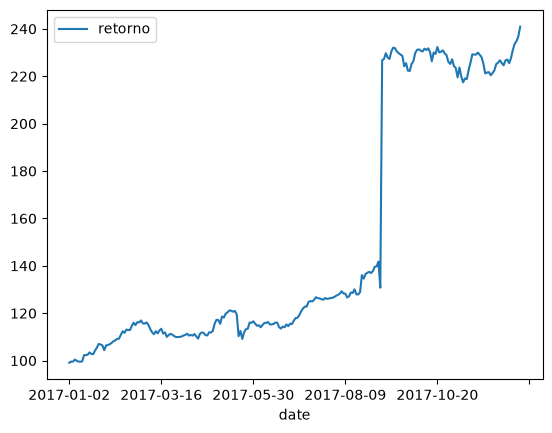

In [ ]:
df.plot()